<a href="https://colab.research.google.com/github/abdullahnoor2685/Anemia_Prediction_Using_Transfer_Learning/blob/main/AlexNet_Tomato_Disease_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tomato Leaf Disease Detection using AlexNet
### Explainable Machine Learning Approach
**Classes:** Bacterial Spot | Early Blight | Late Blight | Leaf Mold | Healthy

---
**Steps in this notebook:**
1. Install libraries & mount Google Drive
2. Load and explore dataset
3. Preprocess and augment images
4. Build AlexNet model
5. Train the model
6. Evaluate (accuracy, F1, confusion matrix)
7. Explainability with Grad-CAM (XAI)
8. Predict on new images

## Step 1 — Install Libraries & Setup

In [1]:
# Install required libraries
!pip install torch torchvision matplotlib seaborn scikit-learn grad-cam Pillow -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from PIL import Image
import os, random, time

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## Step 2 — Mount Google Drive & Set Dataset Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# -------------------------------------------------------
# CHANGE THIS PATH to where your dataset folder is
# Your dataset folder should have subfolders per class:
#   /content/drive/MyDrive/tomato_dataset/Bacterial_Spot/
#   /content/drive/MyDrive/tomato_dataset/Early_Blight/
#   /content/drive/MyDrive/tomato_dataset/Late_Blight/
#   /content/drive/MyDrive/tomato_dataset/Leaf_Mold/
#   /content/drive/MyDrive/tomato_dataset/Healthy/
# -------------------------------------------------------
DATASET_PATH = '/content/drive/MyDrive/Thesis/PlantVillage'  # <-- CHANGE THIS

# Verify the path and show class folders found
if os.path.exists(DATASET_PATH):
    classes = sorted(os.listdir(DATASET_PATH))
    print(f'Found {len(classes)} classes:')
    for i, c in enumerate(classes):
        n = len(os.listdir(os.path.join(DATASET_PATH, c)))
        print(f'  [{i}] {c} — {n} images')
else:
    print('ERROR: Path not found. Please update DATASET_PATH above.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 10 classes:
  [0] Tomato_Bacterial_spot — 2127 images
  [1] Tomato_Early_blight — 1000 images
  [2] Tomato_Late_blight — 1909 images
  [3] Tomato_Leaf_Mold — 952 images
  [4] Tomato_Septoria_leaf_spot — 1771 images
  [5] Tomato_Spider_mites_Two_spotted_spider_mite — 1676 images
  [6] Tomato__Target_Spot — 1404 images
  [7] Tomato__Tomato_YellowLeaf__Curl_Virus — 3209 images
  [8] Tomato__Tomato_mosaic_virus — 373 images
  [9] Tomato_healthy — 1591 images


## Step 3 — Preprocessing & Data Augmentation

In [3]:
# AlexNet expects 227x227 images
IMG_SIZE   = 227
BATCH_SIZE = 32
NUM_CLASSES = 10

# Training transforms: augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    # ImageNet normalization (AlexNet was trained on these values)
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation/Test transforms: NO augmentation, just resize and normalize
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = datasets.ImageFolder(root=DATASET_PATH, transform=train_transforms)
CLASS_NAMES  = full_dataset.classes
print('Class names:', CLASS_NAMES)
print('Total images:', len(full_dataset))

# Split: 70% train, 15% val, 15% test
total = len(full_dataset)
train_size = int(0.70 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Apply val transforms to val and test sets
val_ds.dataset.transform  = val_transforms
test_ds.dataset.transform = val_transforms

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {train_size} | Val: {val_size} | Test: {test_size}')

Class names: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Total images: 16011
Train: 11207 | Val: 2401 | Test: 2403


In [4]:
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def show_samples_fast(dataset, class_names, n=5):

    class_to_indices = {i: [] for i in range(len(class_names))}
    for idx, label in enumerate(dataset.targets):
        class_to_indices[label].append(idx)

    fig, axes = plt.subplots(len(class_names), n, figsize=(15, 3 * len(class_names)))

    for cls_idx, cls_name in enumerate(class_names):
        samples = random.sample(class_to_indices[cls_idx], min(n, len(class_to_indices[cls_idx])))

        for col, idx in enumerate(samples):
            img = Image.open(dataset.samples[idx][0])
            axes[cls_idx, col].imshow(img)
            axes[cls_idx, col].axis("off")

            if col == 0:
                axes[cls_idx, col].set_title(cls_name)

    plt.tight_layout()
    plt.show()

## Step 4 — Build AlexNet Model (Transfer Learning)

In [5]:
def build_alexnet(num_classes=10, pretrained=True, freeze_features=True):
    """
    AlexNet Architecture:
    - 5 Convolutional layers (feature extraction)
    - 3 Fully Connected layers (classification)
    We replace the last FC layer to match our 5 classes.
    """
    # Load pretrained AlexNet (trained on ImageNet)
    model = models.alexnet(pretrained=pretrained)

    # Optionally freeze convolutional layers (transfer learning)
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False
        print('Convolutional layers FROZEN (transfer learning mode)')
    else:
        print('All layers will be trained (fine-tuning mode)')

    # Replace the classifier head for our 5 classes
    # Original AlexNet classifier outputs 1000 classes (ImageNet)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(256 * 6 * 6, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096, num_classes)   # <-- 5 output neurons
    )

    return model

model = build_alexnet(num_classes=NUM_CLASSES, pretrained=True, freeze_features=True)
model = model.to(device)

# Print model summary
print('\nAlexNet Architecture:')
print('=' * 50)
print(model)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Convolutional layers FROZEN (transfer learning mode)

AlexNet Architecture:
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inpl

## Step 5 — Train the Model

In [6]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Auto-detect num classes from actual dataset
NUM_CLASSES = len(full_dataset.classes)
print(f'Detected {NUM_CLASSES} classes: {full_dataset.classes}')

# Rebuild model with correct num_classes
model = build_alexnet(num_classes=NUM_CLASSES, pretrained=True, freeze_features=True)
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=0.001, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

NUM_EPOCHS = 25

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct  += (preds == labels).sum().item()
        total    += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)
    return running_loss / total, correct / total

print(f'Training for {NUM_EPOCHS} epochs on {device}...')
print('=' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_alexnet_tomato.pth')
        saved = ' <-- BEST SAVED'
    else:
        saved = ''

    print(f'Epoch [{epoch:02d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | '
          f'{elapsed:.1f}s{saved}')

print(f'\nBest Validation Accuracy: {best_val_acc:.4f}')

Detected 10 classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Convolutional layers FROZEN (transfer learning mode)
Training for 25 epochs on cuda...
Epoch [01/25] Train Loss: 1.0124 Acc: 0.7088 | Val Loss: 0.3847 Acc: 0.8863 | 1618.3s <-- BEST SAVED
Epoch [02/25] Train Loss: 0.5680 Acc: 0.8165 | Val Loss: 0.4019 Acc: 0.8701 | 74.5s
Epoch [03/25] Train Loss: 0.4943 Acc: 0.8428 | Val Loss: 0.2648 Acc: 0.9175 | 77.4s <-- BEST SAVED
Epoch [04/25] Train Loss: 0.4170 Acc: 0.8703 | Val Loss: 0.2289 Acc: 0.9338 | 75.3s <-- BEST SAVED
Epoch [05/25] Train Loss: 0.3802 Acc: 0.8859 | Val Loss: 0.2476 Acc: 0.9317 | 72.6s
Epoch [06/25] Train Loss: 0.3769 Acc: 0.8870 | Val Loss: 0.2120 Acc: 0.9396 | 72.4s <-- BEST SAVED
Epoch [07/25] Train Loss: 0.3313 Acc: 0.8969 |

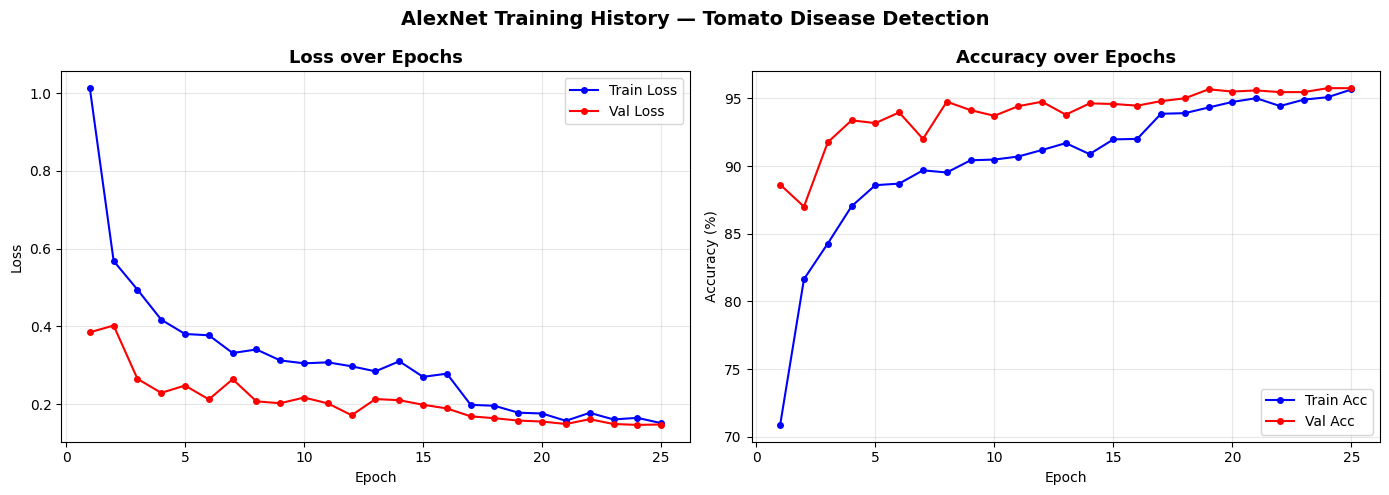

In [7]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
ax1.set_title('Loss over Epochs', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
ax2.plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
ax2.set_title('Accuracy over Epochs', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('AlexNet Training History — Tomato Disease Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6 — Evaluate on Test Set

In [8]:
# Load best saved model
model.load_state_dict(torch.load('best_alexnet_tomato.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification Report
print('TEST SET RESULTS')
print('=' * 60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
test_f1  = f1_score(all_labels, all_preds, average='weighted')
print(f'Overall Test Accuracy : {test_acc*100:.2f}%')
print(f'Weighted F1 Score     : {test_f1:.4f}')

TEST SET RESULTS
                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.96      0.98      0.97       330
                        Tomato_Early_blight       0.84      0.85      0.84       145
                         Tomato_Late_blight       0.94      0.97      0.95       287
                           Tomato_Leaf_Mold       0.98      0.92      0.95       143
                  Tomato_Septoria_leaf_spot       0.99      0.91      0.95       260
Tomato_Spider_mites_Two_spotted_spider_mite       0.94      0.97      0.95       230
                        Tomato__Target_Spot       0.92      0.92      0.92       203
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.99      1.00      1.00       521
                Tomato__Tomato_mosaic_virus       0.95      0.93      0.94        59
                             Tomato_healthy       0.97      0.99      0.98       225

                                   accuracy   

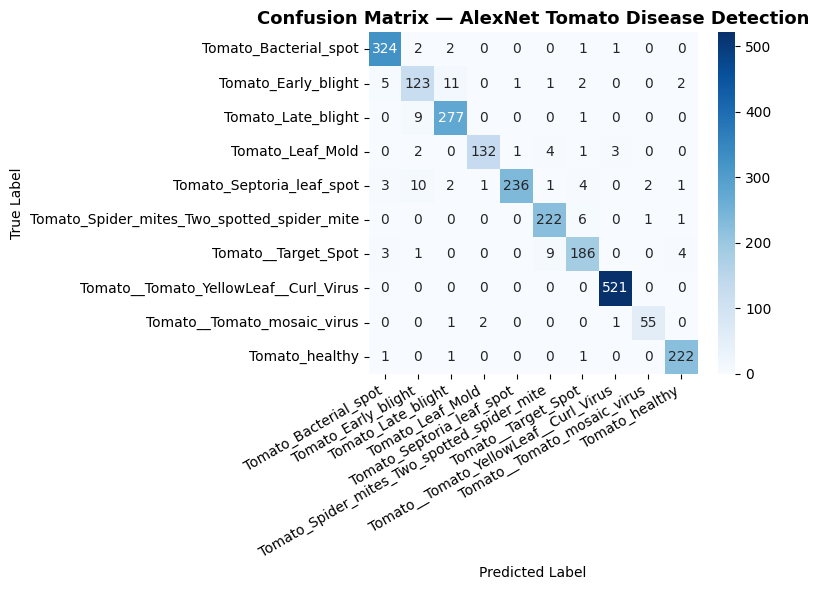

In [9]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — AlexNet Tomato Disease Detection', fontsize=13, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Explainability with Grad-CAM (XAI)

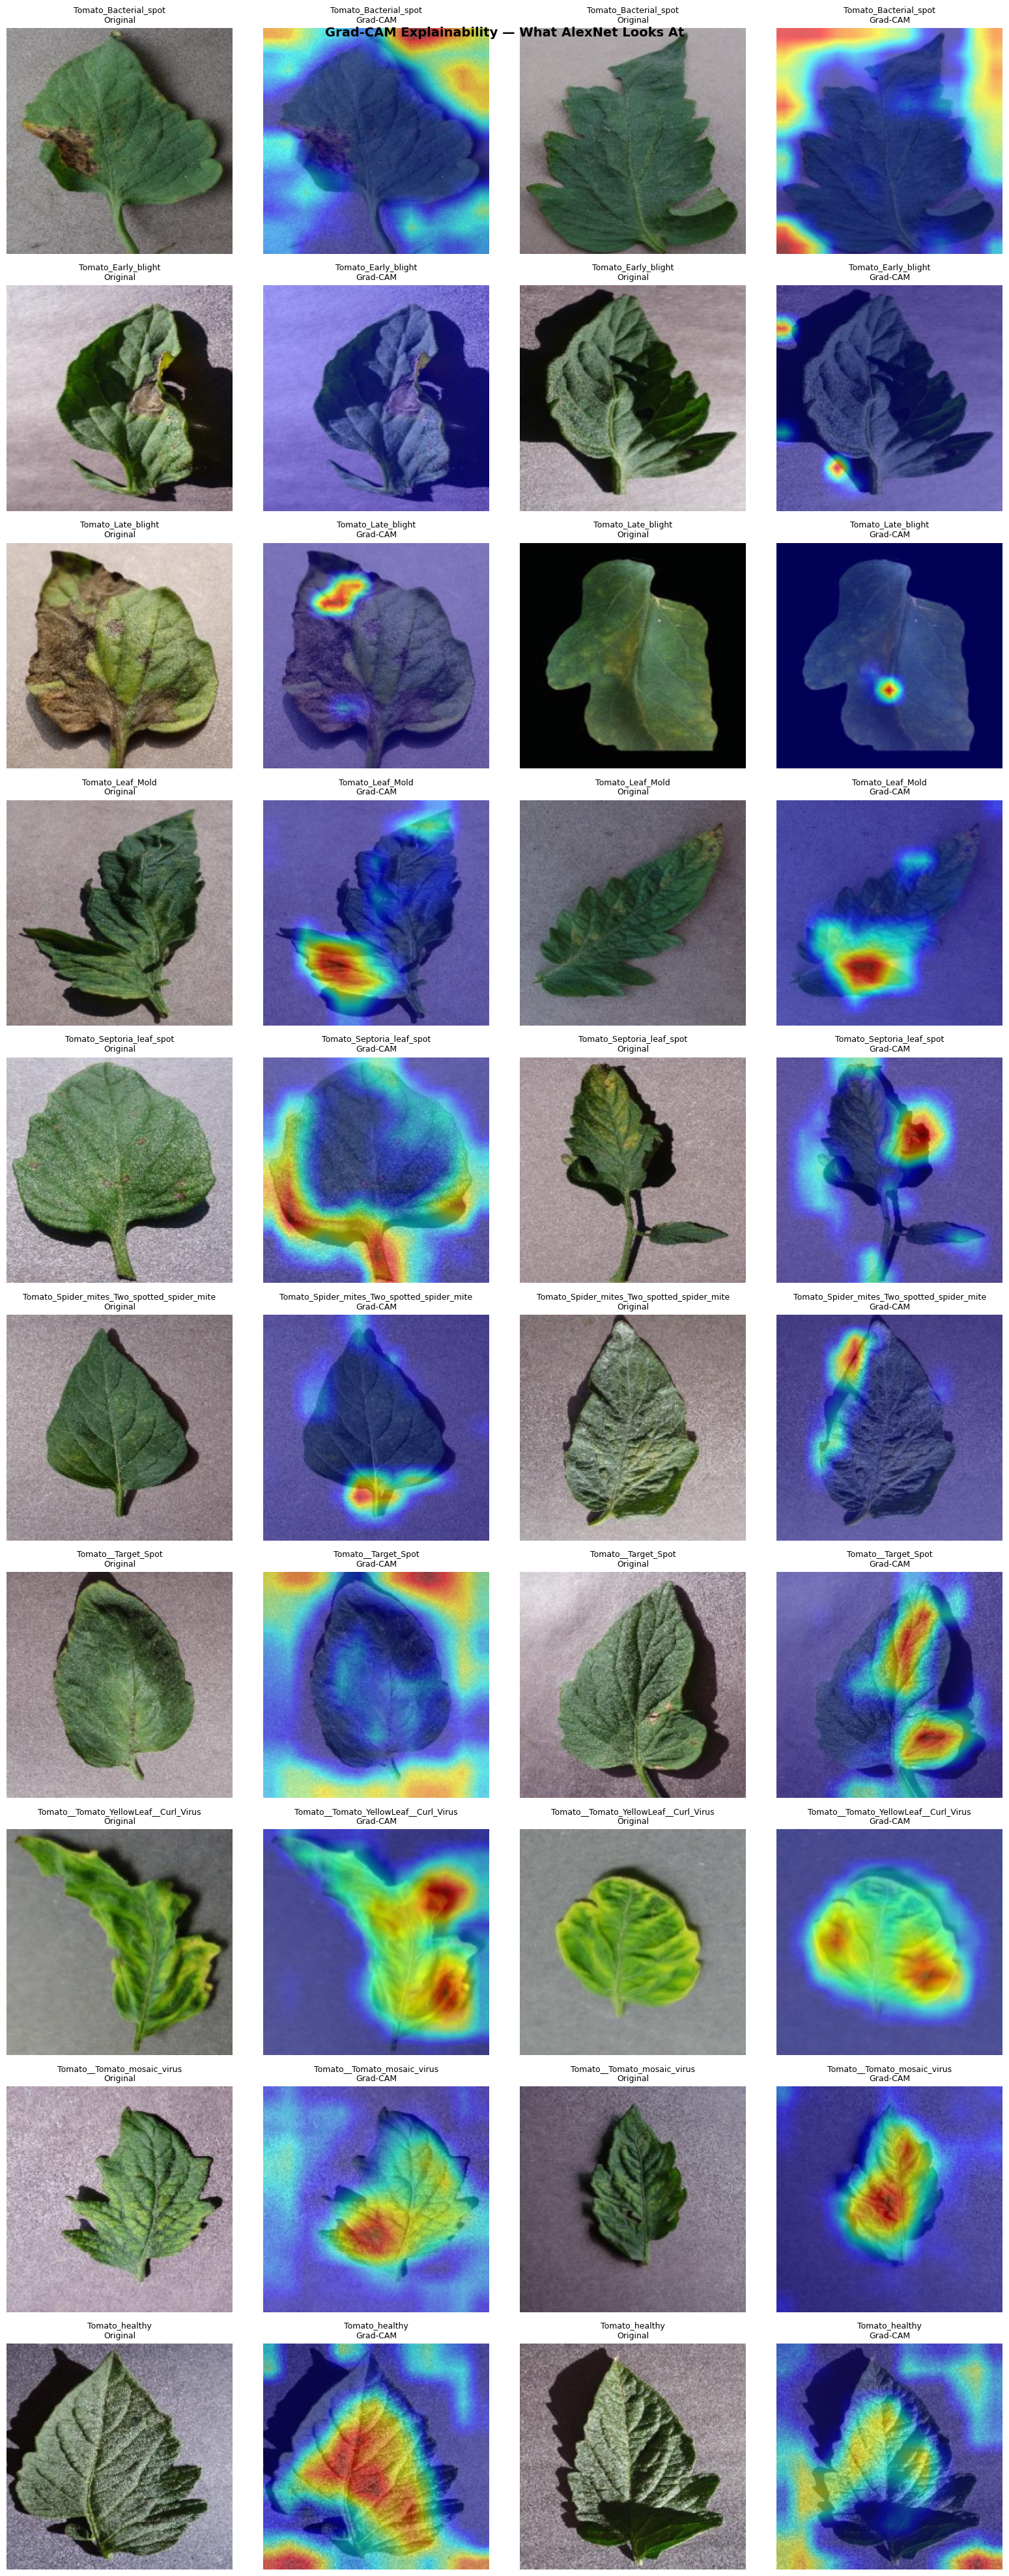

In [11]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Unfreeze last conv layer so Grad-CAM can get gradients
for param in model.features[10].parameters():
    param.requires_grad = True

target_layers = [model.features[10]]
cam = GradCAM(model=model, target_layers=target_layers)

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def visualize_gradcam(dataset, class_names, n_per_class=2):
    fig, axes = plt.subplots(len(class_names), n_per_class * 2,
                              figsize=(4 * n_per_class * 2, 4 * len(class_names)))
    for cls_idx, cls_name in enumerate(class_names):
        cls_indices = [i for i, (_, l) in enumerate(dataset) if l == cls_idx]
        samples = random.sample(cls_indices, min(n_per_class, len(cls_indices)))
        col = 0
        for idx in samples:
            img_tensor, label = dataset[idx]
            input_tensor = img_tensor.unsqueeze(0).to(device)

            img_np = img_tensor.numpy().transpose(1,2,0)
            img_np = np.clip(std * img_np + mean, 0, 1).astype(np.float32)

            grayscale_cam = cam(input_tensor=input_tensor,
                                targets=[ClassifierOutputTarget(cls_idx)])
            cam_image = show_cam_on_image(img_np, grayscale_cam[0], use_rgb=True)

            axes[cls_idx][col].imshow(img_np)
            axes[cls_idx][col].axis('off')
            axes[cls_idx][col].set_title(f'{cls_name}\nOriginal', fontsize=9)

            axes[cls_idx][col+1].imshow(cam_image)
            axes[cls_idx][col+1].axis('off')
            axes[cls_idx][col+1].set_title(f'{cls_name}\nGrad-CAM', fontsize=9)
            col += 2

    plt.suptitle('Grad-CAM Explainability — What AlexNet Looks At',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_gradcam(full_dataset, CLASS_NAMES, n_per_class=2)

## Step 8 — Predict on a New Image

In [12]:
def predict_image(image_path, model, class_names, show_gradcam=True):
    """
    Predict the disease class for a single tomato leaf image.
    Also shows Grad-CAM explanation.
    """
    transform = transforms.Compose([
        transforms.Resize((227, 227)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs   = model(img_tensor)
        probs     = torch.softmax(outputs, dim=1)[0]
        pred_idx  = torch.argmax(probs).item()
        pred_class= class_names[pred_idx]
        confidence= probs[pred_idx].item() * 100

    print(f'Prediction : {pred_class}')
    print(f'Confidence : {confidence:.2f}%')
    print('\nAll class probabilities:')
    for i, (cls, prob) in enumerate(zip(class_names, probs)):
        bar = '=' * int(prob.item() * 30)
        print(f'  {cls:<25} {prob.item()*100:5.2f}% |{bar}')

    # Show image + Grad-CAM
    mean_np = np.array([0.485, 0.456, 0.406])
    std_np  = np.array([0.229, 0.224, 0.225])
    img_np  = img_tensor[0].cpu().numpy().transpose(1,2,0)
    img_np  = np.clip(std_np * img_np + mean_np, 0, 1).astype(np.float32)

    if show_gradcam:
        target_layers = [model.features[10]]
        cam_obj = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam_obj(input_tensor=img_tensor,
                                targets=[ClassifierOutputTarget(pred_idx)])
        cam_image = show_cam_on_image(img_np, grayscale_cam[0], use_rgb=True)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.imshow(img_np); ax1.set_title('Original Image', fontweight='bold'); ax1.axis('off')
        ax2.imshow(cam_image)
        ax2.set_title(f'Grad-CAM: {pred_class} ({confidence:.1f}%)', fontweight='bold')
        ax2.axis('off')
        plt.tight_layout()
        plt.show()

    return pred_class, confidence

# USAGE — change the path to your test image:
# predict_image('/content/drive/MyDrive/test_leaf.jpg', model, CLASS_NAMES)

---
## Summary
| Component | Detail |
|---|---|
| Model | AlexNet (pretrained on ImageNet, fine-tuned) |
| Input size | 227 × 227 × 3 |
| Classes | 5 tomato disease classes |
| Loss | Cross-Entropy |
| Optimizer | Adam (lr=0.001) |
| Scheduler | ReduceLROnPlateau |
| Explainability | Grad-CAM (XAI) |
| Metrics | Accuracy, F1, Confusion Matrix |

In [13]:
!pip install nbconvert -q
!jupyter nbconvert --to html "/content/drive/MyDrive/Thesis/AlexNet_Tomato_Disease (1).ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Thesis/AlexNet_Tomato_Disease (1).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 613343 bytes to /content/drive/MyDrive/Thesis/AlexNet_Tomato_Disease (1).html
